In [29]:
import requests
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
import numpy as np

In [3]:
r = requests.get('https://db.satnogs.org/api/transmitters/?format=json').json()

In [11]:
frequency_range = [2.2e9, 2.3e9]
print('Total transmitters fetched:', len(r))
in_range = []
for transmitter in r:
    freq = transmitter['downlink_low']
    if freq is None: continue
    if frequency_range[0] <= freq <= frequency_range[1]:
        in_range.append(transmitter)

print('Transmitters in range:', len(in_range))
in_range[:5]  # Display first 5 transmitters in range

alive_in_range = [tx for tx in in_range if tx['alive'] == True]
print('Alive transmitters in range:', len(alive_in_range))
alive_in_range[0]

Total transmitters fetched: 4602
Transmitters in range: 937
Alive transmitters in range: 777


{'uuid': 'czwUUACDsHHKTvFyn59tJC',
 'description': 'Mode S',
 'alive': True,
 'type': 'Transmitter',
 'uplink_low': None,
 'uplink_high': None,
 'uplink_drift': None,
 'downlink_low': 2218000000,
 'downlink_high': None,
 'downlink_drift': None,
 'mode': 'FM',
 'mode_id': 1,
 'uplink_mode': None,
 'invert': False,
 'baud': 400000.0,
 'sat_id': 'XTDR-0995-4168-5549-5936',
 'norad_cat_id': 22825,
 'norad_follow_id': None,
 'status': 'active',
 'updated': '2022-08-01T16:52:11.849530Z',
 'citation': 'https://www.itu.int/online/snl/satbandold_snl.sh?ntc_id=119500202&fr1=8000&fr2=8300&ie=y&sat_type=&sat_name=EYESAT&sel_satname=EYESAT&plan_id=',
 'service': 'Unknown',
 'iaru_coordination': 'N/A',
 'iaru_coordination_url': '',
 'itu_notification': {'urls': []},
 'frequency_violation': False,
 'unconfirmed': False}

In [16]:
transmitters_listed = []  # for every item: [sat_norad, sat_name, transmitter_frequency, mode, baud]
for transmitter in tqdm(alive_in_range):
    r = requests.get(f'https://db.satnogs.org/api/satellites/?sat_id={transmitter["sat_id"]}&format=json').json()[0]
    if r['decayed']: continue
    transmitters_listed.append([
        r['norad_cat_id'],
        r['name'],
        transmitter['downlink_low'],
        transmitter['mode'],
        transmitter['baud'],
    ])


100%|██████████| 777/777 [06:56<00:00,  1.86it/s]


In [19]:
with open('satnogs_transmitters_in_2.2-2.3GHz_alive.json', 'w') as f:
    json.dump(transmitters_listed, f, indent=2)

transmitters_listed[:5]

[[22825, 'EYESAT-1', 2218000000, 'FM', 400000.0],
 [25338, 'NOAA 15', 2247490000, 'BPSK', 128000.0],
 [25544, 'ISS', 2265000000, 'QPSK', None],
 [25544, 'ISS', 2205500000, 'BPSK', None],
 [25544, 'ISS', 2216000000, 'BPSK', None]]

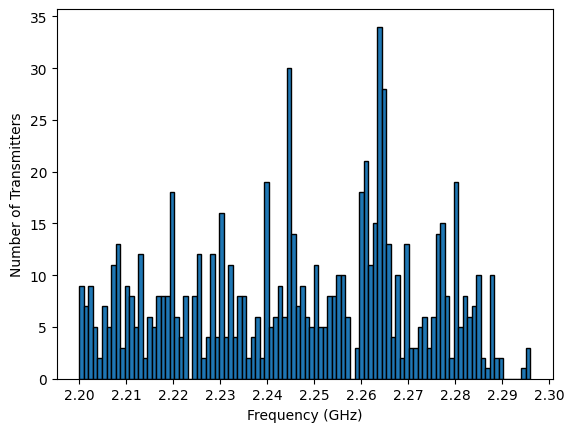

In [30]:
frequencies = [tx[2]/1e9 for tx in transmitters_listed]
plt.hist(frequencies, bins=100, edgecolor='black')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Number of Transmitters')
plt.xticks(np.arange(2.2, 2.31, 0.01))
plt.show()


In [27]:
# Most common frequencies:
from collections import Counter
frequency_counts = Counter(frequencies)
most_common = frequency_counts.most_common(10)
print("Most common frequencies (GHz) and their counts:")
for freq, count in most_common:
    print(f"{freq:.6f} GHz: {count} transmitters")

Most common frequencies (GHz) and their counts:
2.245000 GHz: 24 transmitters
2.260500 GHz: 20 transmitters
2.240000 GHz: 18 transmitters
2.280000 GHz: 17 transmitters
2.260000 GHz: 17 transmitters
2.220000 GHz: 14 transmitters
2.263500 GHz: 13 transmitters
2.264000 GHz: 11 transmitters
2.264500 GHz: 11 transmitters
2.230000 GHz: 10 transmitters
